In [1]:
import os
import glob
import pickle
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.colors as colors

In [2]:
# # =============

# # Buscar todos los archivos que comiencen con "spectra_data_complete" en la carpeta "data"
# data_files = glob.glob(os.path.join('data', 'spectra_data_complete*.pkl'))
# data_files = sorted(data_files)
# print(f"Se encontraron {len(data_files)} archivos pickle.")

# # Primer paso: contar el número total de espectros
# total_spectra = 0
# for file in data_files:
#     with open(file, 'rb') as f:
#         data_part = pickle.load(f)
#     total_spectra += len(data_part)
# print(f"Total de espectros: {total_spectra}")

# # Prealocar archivos memmap para flux, wavelength y redshift en la carpeta 'data'
# flux_mmap_path = os.path.join('data', 'flux_mmap.dat')
# wavelength_mmap_path = os.path.join('data', 'wavelength_mmap.dat')
# redshift_mmap_path = os.path.join('data', 'redshift_mmap.dat')

# flux_mmap = np.memmap(flux_mmap_path, dtype='float32', mode='w+', shape=(total_spectra, num_points))
# wavelength_mmap = np.memmap(wavelength_mmap_path, dtype='float32', mode='w+', shape=(total_spectra, num_points))
# redshift_mmap = np.memmap(redshift_mmap_path, dtype='float32', mode='w+', shape=(total_spectra,))

# # Segundo pase: cargar datos de los archivos pickle y escribirlos en los memmaps
# current_index = 0
# for file in data_files:
#     with open(file, 'rb') as f:
#         data_part = pickle.load(f)
#     print(f"Procesando {file} con {len(data_part)} espectros...")
#     for key in data_part:
#         espectro = data_part[key]
#         flux = espectro["flux"]         # Array de 5000 puntos
#         wavelength = espectro["wavelength"]  # Array de 5000 puntos
#         redshift = espectro["redshift"]      # Valor escalar
        
#         # Almacenar en el memmap
#         flux_mmap[current_index, :] = flux
#         wavelength_mmap[current_index, :] = wavelength
#         redshift_mmap[current_index] = redshift
        
#         current_index += 1

# # Asegurar que todos los cambios se escriban en disco
# flux_mmap.flush()
# wavelength_mmap.flush()
# redshift_mmap.flush()

# print("Se han guardado los datos en archivos memmap dentro de la carpeta 'data'.")

In [3]:
# =============
# Model Evaluation

# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Número de puntos en cada espectro
num_points = 5000

# Definir el modelo CNN en PyTorch con dropout para regularización
class CNN(nn.Module):
    def __init__(self, num_points):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            # Bloque 1
            nn.Conv1d(in_channels=2, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            # Bloque 2
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            # Bloque 3
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            # Bloque 4 (capa adicional)
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            # Bloque 5 (capa adicional)
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        # Con 5 capas de max pooling, la dimensión se reduce en un factor de 2^5 = 32
        conv_output_size = num_points // 32
        self.fc_layers = nn.Sequential(
            nn.Linear(256 * conv_output_size, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),  # Regularización con Dropout
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

scaler = StandardScaler()

# Instanciar el modelo y moverlo a GPU si está disponible
modelCNN = CNN(num_points).to(device)

# Definir la función de pérdida
criterion = nn.MSELoss()

# Utilizar Adam con un weight decay para regularización L2
optimizer = optim.Adam(modelCNN.parameters(), lr=0.0001, weight_decay=1e-4)

# Scheduler adaptativo: ReduceLROnPlateau reduce la lr si la pérdida de validación no mejora
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

Usando dispositivo: cuda


In [4]:
class SpectraMemmapDataset(Dataset):
    def __init__(self, flux_file, wavelength_file, redshift_file, total_spectra, num_points, scaler_path):
        # Cargar los archivos memmap en modo lectura
        self.flux = np.memmap(flux_file, dtype='float32', mode='r', shape=(total_spectra, num_points))
        self.wavelength = np.memmap(wavelength_file, dtype='float32', mode='r', shape=(total_spectra, num_points))
        self.redshift = np.memmap(redshift_file, dtype='float32', mode='r', shape=(total_spectra,))
        self.total_spectra = total_spectra
        self.num_points = num_points
        
        # Cargar el scaler preajustado
        with open(scaler_path, 'rb') as f:
            self.scaler = pickle.load(f)
    
    def __len__(self):
        return self.total_spectra
    
    def __getitem__(self, idx):
        # Extraer los datos para el espectro idx
        flux = self.flux[idx]
        wavelength = self.wavelength[idx]
        redshift = self.redshift[idx]
        
        # Combinar flux y wavelength en un array de forma (2, num_points)
        x = np.stack([flux, wavelength], axis=0)
        # Aplanar para aplicar la normalización
        x_flat = x.flatten().reshape(1, -1)
        x_scaled_flat = self.scaler.transform(x_flat)
        x_scaled = x_scaled_flat.reshape(2, self.num_points)
        
        # Convertir a tensores
        x_tensor = torch.tensor(x_scaled, dtype=torch.float32)
        y_tensor = torch.tensor(redshift, dtype=torch.float32)
        return x_tensor, y_tensor

total_spectra = 3372890
total_spectra = 460000
num_points = 5000
scaler_path = 'extra/scaler_modelCNN_UPD3_100ktest.pkl'

# Crear el dataset y el DataLoader
dataset = SpectraMemmapDataset('data/spectra_data_500k_flux_mmap.dat', 'data/spectra_data_500k_wavelength_mmap.dat', 'data/spectra_data_500k_redshift_mmap.dat',
                               total_spectra, num_points, scaler_path)
dataloader = DataLoader(dataset, batch_size=20000, shuffle=False)

# Instanciar el modelo y cargar el checkpoint
modelCNN = CNN(num_points).to(device)
checkpoint = torch.load('storage/modelCNN_UPD3_100ktest.pth', weights_only=False)
modelCNN.load_state_dict(checkpoint['model_state_dict'])

# Evaluación del modelo utilizando el DataLoader
modelCNN.eval()
all_preds = []
all_y = []
with torch.no_grad():
    for x_batch, y_batch in dataloader:
        x_batch = x_batch.to(device)
        preds = modelCNN(x_batch).cpu().numpy()
        all_preds.append(preds)
        all_y.append(y_batch.numpy())

ypredicted = np.concatenate(all_preds, axis=0)
yreal = np.concatenate(all_y, axis=0)
lincorr = np.corrcoef(yreal, ypredicted.squeeze())
print(f"Correlación lineal: {lincorr[0, 1]}")
print(f"Número de muestras: {len(yreal)}")

Correlación lineal: 0.9609591154435922
Número de muestras: 460000


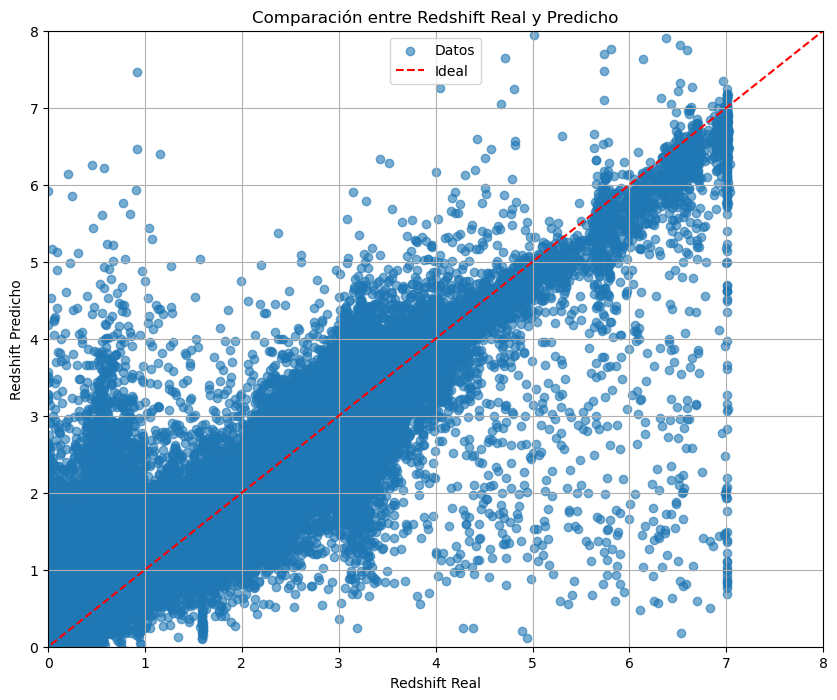

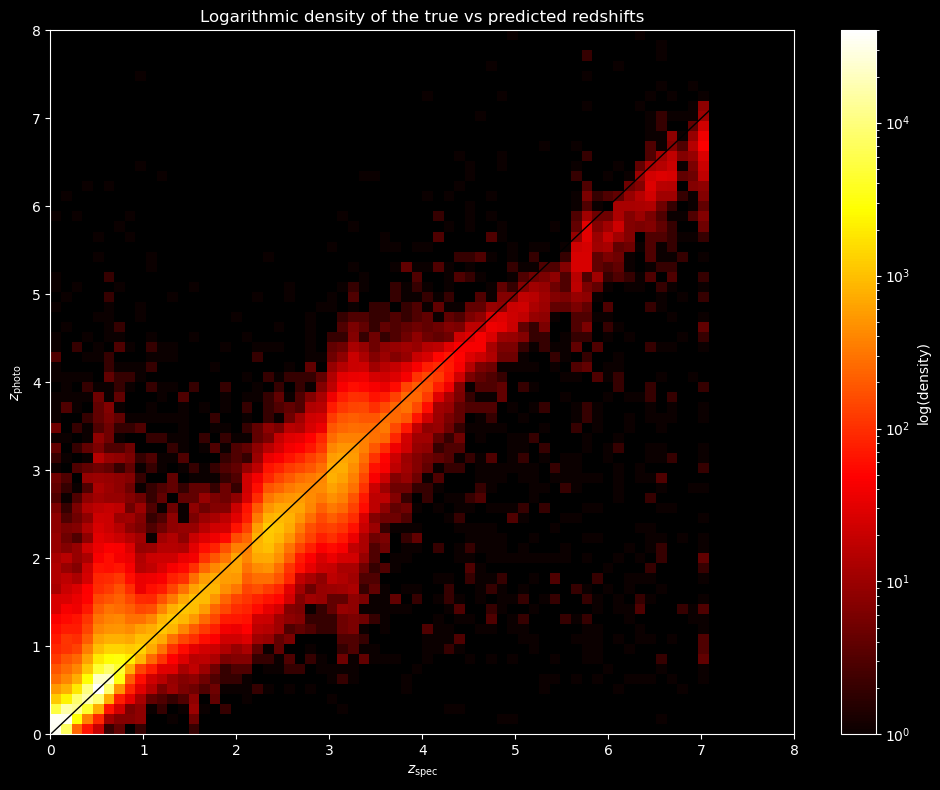

In [5]:
plt.rcdefaults()
plt.figure(figsize=(10, 8))
plt.scatter(yreal, ypredicted, alpha=0.6, label='Datos')
plt.xlabel('Redshift Real')
plt.ylabel('Redshift Predicho')
plt.title('Comparación entre Redshift Real y Predicho')
# Añadir la línea ideal (y=x)
min_val = min(yreal.min(), ypredicted.min())
max_val = max(yreal.max(), ypredicted.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')
plt.legend()
plt.grid(True)
plt.xlim(0, 8)
plt.ylim(0, 8)
plt.show()







# Estilo de fondo oscuro (opcional)
plt.style.use('dark_background')

# Rango de ejes (ajústalo a tus necesidades)
x_min, x_max = 0, 8
y_min, y_max = 0, 8

plt.figure(figsize=(10, 8))

# Generamos el histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                # z_spec (redshift "real")
    ypredicted[:, 0],     # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

# Barra de color con etiqueta
cbar = plt.colorbar(im, label='log(density)')

# Trazamos la línea diagonal z_spec = z_photo
plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)

# Etiquetas de ejes
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')

# Título (opcional)
plt.title('Logarithmic density of the true vs predicted redshifts')

# Ajustamos los límites para que coincidan con el rango
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()

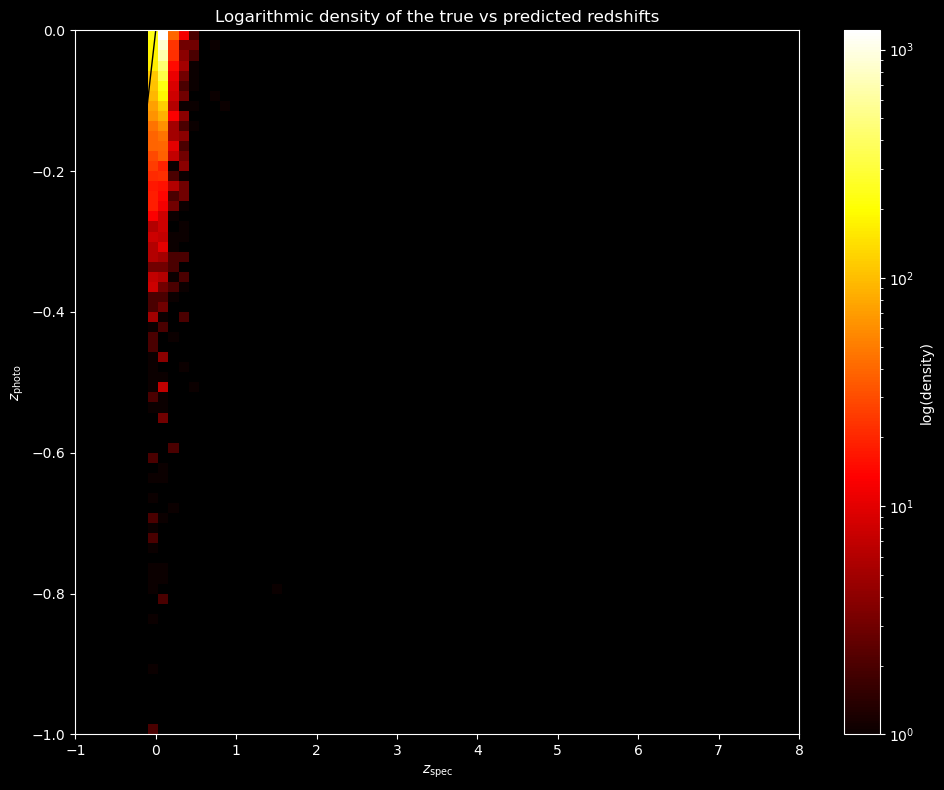

In [6]:
# Estilo de fondo oscuro (opcional)
plt.style.use('dark_background')

# Rango de ejes (ajústalo a tus necesidades)
x_min, x_max = -1, 8
y_min, y_max = -1, 0

plt.figure(figsize=(10, 8))

# Generamos el histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                # z_spec (redshift "real")
    ypredicted[:, 0],     # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

# Barra de color con etiqueta
cbar = plt.colorbar(im, label='log(density)')

# Trazamos la línea diagonal z_spec = z_photo
plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)

# Etiquetas de ejes
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')

# Título (opcional)
plt.title('Logarithmic density of the true vs predicted redshifts')

# Ajustamos los límites para que coincidan con el rango
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()

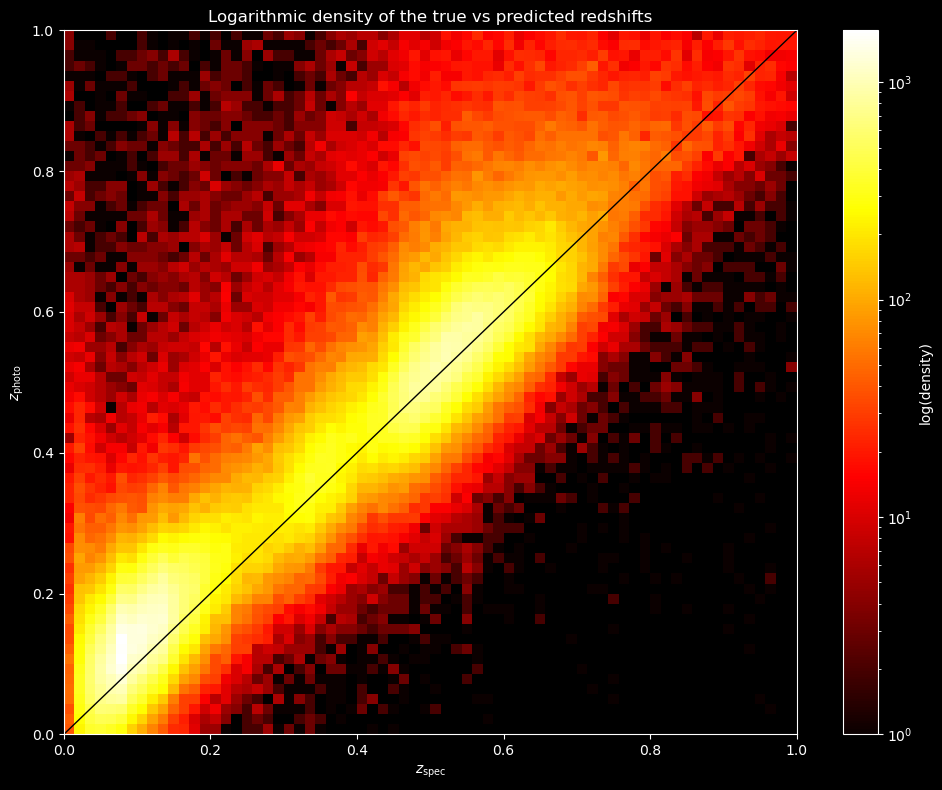

In [7]:
# Estilo de fondo oscuro (opcional)
plt.style.use('dark_background')

# Rango de ejes (ajústalo a tus necesidades)
x_min, x_max = 0, 1
y_min, y_max = 0, 1

plt.figure(figsize=(10, 8))

# Generamos el histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                # z_spec (redshift "real")
    ypredicted[:, 0],     # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

# Barra de color con etiqueta
cbar = plt.colorbar(im, label='log(density)')

# Trazamos la línea diagonal z_spec = z_photo
plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)

# Etiquetas de ejes
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')

# Título (opcional)
plt.title('Logarithmic density of the true vs predicted redshifts')

# Ajustamos los límites para que coincidan con el rango
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()

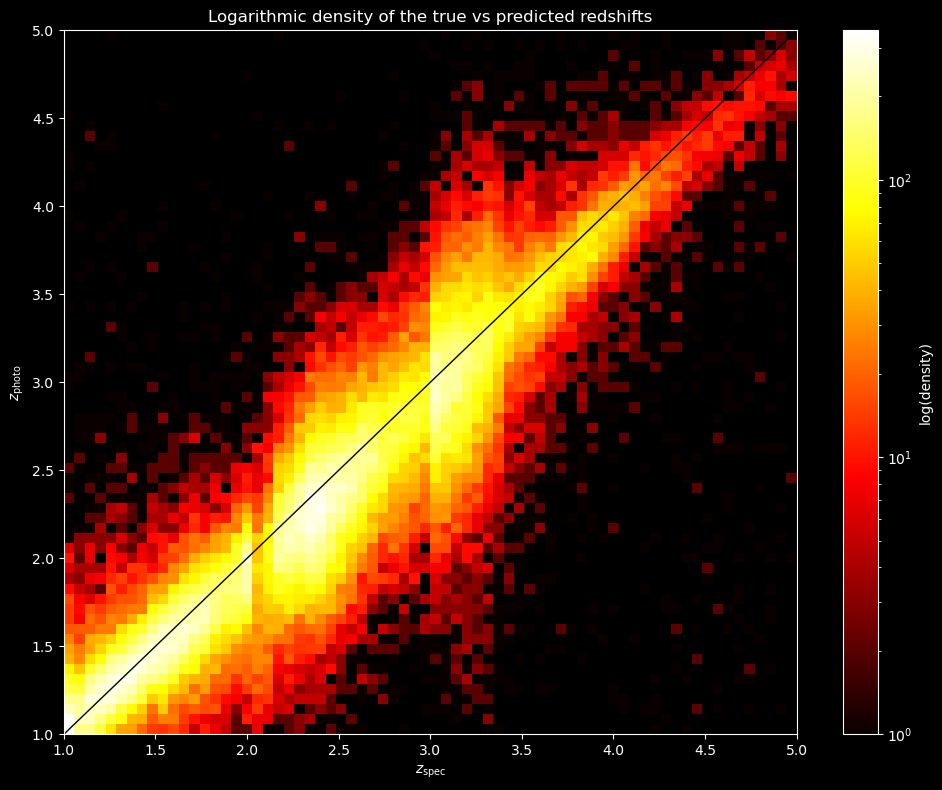

In [8]:
# Estilo de fondo oscuro (opcional)
plt.style.use('dark_background')

# Rango de ejes (ajústalo a tus necesidades)
x_min, x_max = 1, 5
y_min, y_max = 1, 5

plt.figure(figsize=(10, 8))

# Generamos el histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                # z_spec (redshift "real")
    ypredicted[:, 0],     # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

# Barra de color con etiqueta
cbar = plt.colorbar(im, label='log(density)')

# Trazamos la línea diagonal z_spec = z_photo
plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)

# Etiquetas de ejes
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')

# Título (opcional)
plt.title('Logarithmic density of the true vs predicted redshifts')

# Ajustamos los límites para que coincidan con el rango
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()

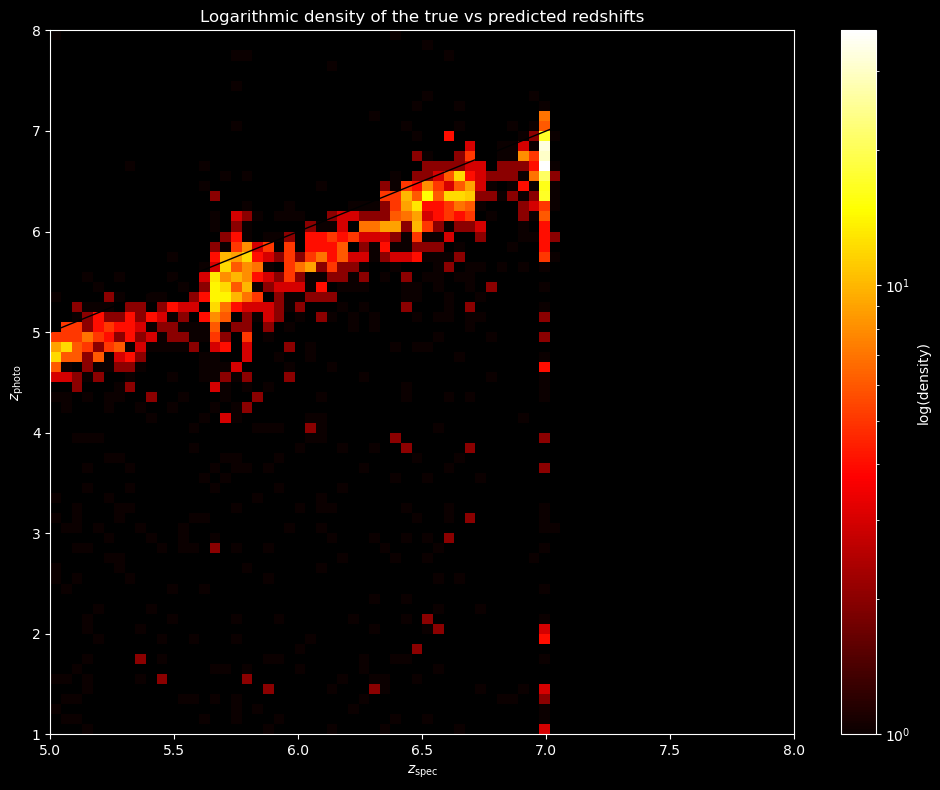

In [9]:
# Estilo de fondo oscuro (opcional)
plt.style.use('dark_background')

# Rango de ejes (ajústalo a tus necesidades)
x_min, x_max = 5, 8
y_min, y_max = 1, 8

plt.figure(figsize=(10, 8))

# Generamos el histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                # z_spec (redshift "real")
    ypredicted[:, 0],     # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

# Barra de color con etiqueta
cbar = plt.colorbar(im, label='log(density)')

# Trazamos la línea diagonal z_spec = z_photo
plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)

# Etiquetas de ejes
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')

# Título (opcional)
plt.title('Logarithmic density of the true vs predicted redshifts')

# Ajustamos los límites para que coincidan con el rango
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()